# Getting started

## What is a KPNN?

A knowledge-primed neural network (KPNN) uses prior knowledge encoded as a
graph to constrain the structure of a neural network. Instead of starting from
a fully generic architecture, the model structure is informed by known
relationships between named entities.

The figure below illustrates the general idea of KPNNs.

![KPNNs explained](../figures/KPNNs_explained.svg)

## What does `kpnn` do?

`kpnn` implements this idea as a graph-to-model compiler plus
model-to-interpretation bridge.

The figure below summarizes the overall `kpnn` workflow.

<img src="../figures/graphical_abstract.svg"
     alt="Graphical abstract of kpnn"
     style="width: 100%; max-width: 100%;">

This notebook shows the basic `kpnn` workflow:

1. represent prior knowledge as an edgelist
2. compile the graph into a PyTorch model
3. use the compiled model like ordinary PyTorch
4. interpret the model back in biological space


## Installation

Install `kpnn` from PyPI with:

```bash
pip install kpnn
```

For optional `AnnData` support:

```bash
pip install "kpnn[bio]"
```


## Imports

In [2]:
import pandas as pd
from graphviz import Digraph
import torch
from torch import nn
from IPython.display import display

from kpnn.compile_graph import compile_graph
from kpnn.interpret_model import interpret_model

/home/thomas/Documents/PhD/projects/KPNN/kpnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: define a prior-knowledge graph

For v1, `kpnn` expects an edgelist with two required columns:

- `source`
- `target`

Here we define a larger feedforward biological graph with three gene inputs,
three hidden protein layers, and one output node. The example also includes
skip edges so the feedforward compiler has to expand them internally into
pseudo nodes.


In [3]:
edgelist = pd.DataFrame(
    {
        "source": [
            "gene_1",
            "gene_2",
            "gene_2",
            "gene_3",
            "tf_1",
            "tf_2",
            "tf_2",
            "kinase_1",
            "kinase_2",
            "phosphatase_1",
            "gene_1",
            "tf_2",
        ],
        "target": [
            "tf_1",
            "tf_1",
            "tf_2",
            "tf_2",
            "kinase_1",
            "kinase_1",
            "kinase_2",
            "phosphatase_1",
            "phosphatase_1",
            "output_1",
            "kinase_1",
            "output_1",
        ],
    }
)

edgelist

,source,target
0,gene_1,tf_1
1,gene_2,tf_1
2,gene_2,tf_2
3,gene_3,tf_2
4,tf_1,kinase_1
5,tf_2,kinase_1
6,tf_2,kinase_2
7,kinase_1,phosphatase_1
8,kinase_2,phosphatase_1
9,phosphatase_1,output_1


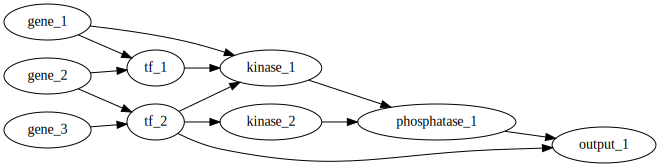

In [4]:
dot = Digraph()
dot.attr(rankdir="LR")

input_nodes = ["gene_1", "gene_2", "gene_3"]
layer_1_nodes = ["tf_1", "tf_2"]
layer_2_nodes = ["kinase_1", "kinase_2"]
layer_3_nodes = ["phosphatase_1"]
output_nodes = ["output_1"]

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in input_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_1_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_2_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in layer_3_nodes:
        s.node(node, node)

with dot.subgraph() as s:
    s.attr(rank="same")
    for node in output_nodes:
        s.node(node, node)

for _, row in edgelist.iterrows():
    dot.edge(row["source"], row["target"])

dot

## Step 2: compile the graph

`compile_graph(...)` returns:

- a compiled PyTorch model
- a compilation artifact containing the metadata needed later for
  interpretation


In [5]:
model, artifact = compile_graph(
    edgelist=edgelist,
    backend="feedforward",
)

type(model), type(artifact)

[kpnn] Note: Graph contains 9 node(s) and 12 edge(s).
[kpnn] Note: Feedforward backend selected. Graph must be layerable.


(kpnn.nn.model.KPNNModel, kpnn.compile.artifact.KPNNArtifact)

## Inspect the artifact

The artifact is the bridge between compilation and interpretation.


In [6]:
artifact.backend

'feedforward'

In [7]:
artifact.feature_names

['gene_1', 'gene_2', 'gene_3']

In [8]:
artifact.node_names_by_layer

{'layer_0': ['gene_1', 'gene_2', 'gene_3'],
 'layer_1': ['pseudo__gene_1__kinase_1__layer_1', 'tf_1', 'tf_2'],
 'layer_2': ['kinase_1', 'kinase_2', 'pseudo__tf_2__output_1__layer_2'],
 'layer_3': ['phosphatase_1', 'pseudo__tf_2__output_1__layer_3'],
 'layer_4': ['output_1']}

## Step 3: run the compiled model

The compiled model is a normal PyTorch module.


In [9]:
x = torch.randn(4, len(artifact.feature_names))
y = model(x)

y

tensor([[0.4242],
        [0.1118],
        [0.6924],
        [0.3911]], grad_fn=<AddmmBackward0>)

In [10]:
y.shape

torch.Size([4, 1])

## Step 4: use the compiled model inside ordinary PyTorch

`kpnn` does not impose activations, output heads, loss functions,
optimizers, or training loops.

A common pattern is to wrap the compiled model inside your own PyTorch
module.


In [11]:
class WrappedModel(nn.Module):
    def __init__(self, compiled_model):
        super().__init__()
        self.compiled_model = compiled_model
        self.activation = nn.ReLU()
        self.head = nn.Linear(1, 1)

    def forward(self, x):
        x = self.compiled_model(x)
        x = self.activation(x)
        x = self.head(x)
        return x


wrapped_model = WrappedModel(model)
wrapped_model

WrappedModel(
  (compiled_model): KPNNModel(
    (blocks): ModuleList(
      (0-3): 4 x FeedforwardLayerBlock(
        (linear): MaskedLinear()
      )
    )
  )
  (activation): ReLU()
  (head): Linear(in_features=1, out_features=1, bias=True)
)

### A minimal training step

This is only a small PyTorch example to show that the compiled model can be
used inside an ordinary training workflow.


In [12]:
optimizer = torch.optim.Adam(wrapped_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

x_train = torch.randn(8, len(artifact.feature_names))
y_true = torch.randn(8, 1)

optimizer.zero_grad()
y_pred = wrapped_model(x_train)
loss = loss_fn(y_pred, y_true)
loss.backward()
optimizer.step()

loss.item()

1.0352839231491089

## Step 5: feature-level interpretation

Feature-level interpretation maps attributions back to the input features.

Current intended combination:

- `target="features"`
- `method="integrated_gradients"`


In [13]:
feature_data = pd.DataFrame(
    {
        "gene_1": [0.1, 0.2, 0.3],
        "gene_2": [1.0, 1.1, 1.2],
        "gene_3": [0.5, 0.4, 0.6],
    },
    index=["cell_1", "cell_2", "cell_3"],
)

feature_data

,gene_1,gene_2,gene_3
cell_1,0.1,1.0,0.5
cell_2,0.2,1.1,0.4
cell_3,0.3,1.2,0.6


In [14]:
feature_attr = interpret_model(
    model=model,
    artifact=artifact,
    data=feature_data,
    target="features",
    method="integrated_gradients",
)

feature_attr

[kpnn] Finished interpretation with method 'integrated_gradients' for target 'features'.


,gene_1,gene_2,gene_3
cell_1,0.000174,0.187450,-0.050544
cell_2,0.000349,0.206195,-0.040435
cell_3,0.000523,0.224940,-0.060653


The returned object is a pandas DataFrame:

- rows = examples
- columns = feature names


## Step 6: node-level interpretation

Node-level interpretation maps attributions back to biological nodes inside
the compiled network.

Current intended combinations:

- `target="nodes", method="layer_conductance"`
- `target="nodes", method="layer_integrated_gradients"`


In [15]:
node_attr = interpret_model(
    model=model,
    artifact=artifact,
    data=feature_data,
    target="nodes",
    method="layer_conductance",
)

node_attr

[kpnn] Finished interpretation with method 'layer_conductance' for target 'nodes'.


{'layer_1':             tf_1      tf_2
 cell_1  0.000462  0.136271
 cell_2  0.000487  0.165045
 cell_3  0.000513  0.163526,
 'layer_2':         kinase_1  kinase_2
 cell_1 -0.002647  0.022182
 cell_2 -0.003123  0.026866
 cell_3 -0.002863  0.026619,
 'layer_3':         phosphatase_1
 cell_1       0.019535
 cell_2       0.023744
 cell_3       0.023756,
 'layer_4':         output_1
 cell_1  0.136930
 cell_2  0.165927
 cell_3  0.164630}

The returned object is a dictionary:

- keys = layer names such as `"layer_1"` and `"layer_2"`
- values = pandas DataFrames with:
  - rows = examples
  - columns = biological node names in that layer

Internal pseudo nodes are filtered out of returned interpretation results.


In [16]:
for layer_name, layer_df in node_attr.items():
    print(layer_name)
    display(layer_df)

layer_1


,tf_1,tf_2
cell_1,0.000462,0.136271
cell_2,0.000487,0.165045
cell_3,0.000513,0.163526


layer_2


,kinase_1,kinase_2
cell_1,-0.002647,0.022182
cell_2,-0.003123,0.026866
cell_3,-0.002863,0.026619


layer_3


,phosphatase_1
cell_1,0.019535
cell_2,0.023744
cell_3,0.023756


layer_4


,output_1
cell_1,0.136930
cell_2,0.165927
cell_3,0.164630


## Optional: layer integrated gradients

You can also compute node-level attributions with layer integrated
gradients.


In [17]:
node_attr_lig = interpret_model(
    model=model,
    artifact=artifact,
    data=feature_data,
    target="nodes",
    method="layer_integrated_gradients",
)

node_attr_lig

[kpnn] Finished interpretation with method 'layer_integrated_gradients' for target 'nodes'.


{'layer_1':             tf_1      tf_2
 cell_1  0.000462  0.136420
 cell_2  0.000488  0.165225
 cell_3  0.000513  0.163704,
 'layer_2':         kinase_1  kinase_2
 cell_1 -0.002650  0.022207
 cell_2 -0.003126  0.026896
 cell_3 -0.002866  0.026648,
 'layer_3':         phosphatase_1
 cell_1       0.019557
 cell_2       0.023770
 cell_3       0.023782,
 'layer_4':         output_1
 cell_1  0.137080
 cell_2  0.166108
 cell_3  0.164810}

## Example with a skip edge

For feedforward compilation, skip edges are expanded internally into pseudo
nodes so the graph can still be computed layer by layer.

These pseudo nodes are internal only and do not appear in biological
interpretation outputs.

The figure below illustrates the idea.

![Pseudo nodes explained](../figures/pseudo_nodes_explained.svg)

In [18]:
skip_edgelist = pd.DataFrame(
    {
        "source": [
            "gene_1",
            "pathway_1",
            "pathway_2",
            "gene_1",
        ],
        "target": [
            "pathway_1",
            "pathway_2",
            "output_1",
            "output_1",
        ],
    }
)

skip_model, skip_artifact = compile_graph(skip_edgelist)
skip_artifact.node_names_by_layer

[kpnn] Note: Graph contains 4 node(s) and 4 edge(s).
[kpnn] Note: Feedforward backend selected. Graph must be layerable.


{'layer_0': ['gene_1'],
 'layer_1': ['pathway_1', 'pseudo__gene_1__output_1__layer_1'],
 'layer_2': ['pathway_2', 'pseudo__gene_1__output_1__layer_2'],
 'layer_3': ['output_1']}

In [19]:
skip_data = pd.DataFrame(
    {"gene_1": [0.1, 0.2]},
    index=["cell_1", "cell_2"],
)

skip_node_attr = interpret_model(
    model=skip_model,
    artifact=skip_artifact,
    data=skip_data,
    target="nodes",
    method="layer_conductance",
)

skip_node_attr

[kpnn] Finished interpretation with method 'layer_conductance' for target 'nodes'.


{'layer_1':         pathway_1
 cell_1  -0.002474
 cell_2  -0.004948,
 'layer_2':         pathway_2
 cell_1  -0.002474
 cell_2  -0.004948,
 'layer_3':         output_1
 cell_1 -0.008669
 cell_2 -0.017338}

Notice that the returned node-level output contains only biological nodes,
not internal pseudo nodes.


## Summary

The basic `kpnn` workflow is:

1. define a biological edgelist
2. compile it into a PyTorch model with `compile_graph(...)`
3. train or wrap the model using ordinary PyTorch
4. map attributions back to biology with `interpret_model(...)`

This keeps the public API small while preserving normal PyTorch flexibility.